Initial goal:

Generate datasets of sinusoid tones, fading in, fading out, with reverb and overlap.

In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
#| default_exp tone_element

In [ ]:
#| export
from audiolazy import Stream, sinusoid, sHz, line, zeros, ones

In [ ]:
Stream(-1, 1).take(10)

[-1, 1, -1, 1, -1, 1, -1, 1, -1, 1]

In [ ]:
from matplotlib import pyplot as plt

In [ ]:
#| export
db2amp = lambda db: 10 ** (db / 20)

In [ ]:
rate = 44100
s, Hz = sHz(rate)

freq = 440
db = -6

sine = sinusoid(freq * Hz) * db2amp(db)

In [ ]:
# player = AudioIO()
# player.play(sine)
# no player as yet...

[<matplotlib.lines.Line2D>]

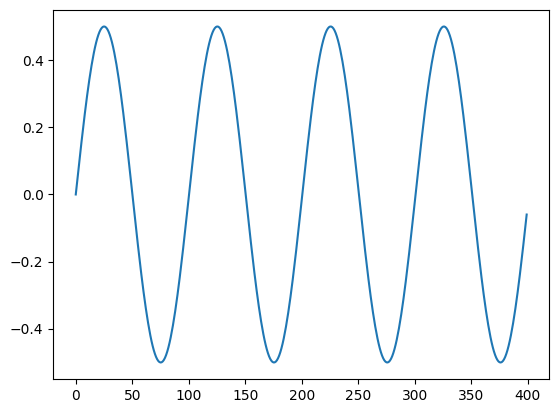

In [ ]:
plt.plot(sine.take(400))

Variables:

- volume
- pitch
- fade-in and -out lengths
- ...

[<matplotlib.lines.Line2D>]

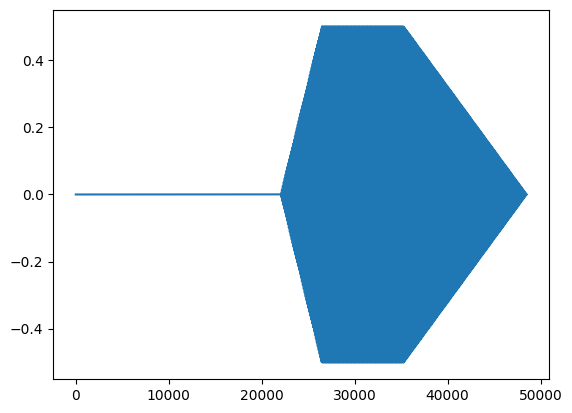

In [ ]:
delay = 0.5
attack = 0.1
sustain = 0.2
release = 0.3

envelope = Stream(zeros(s * delay), line(s * attack, 0, 1), ones(s * sustain), line(s * release, 1, 0))
plt.plot(list(envelope * sine))

In [ ]:
#| export
def tone(freq, db, delay, attack, sustain, release, rate=44100):
    s, Hz = sHz(rate)
    sine = sinusoid(freq * Hz) * db2amp(db)
    envelope = Stream(zeros(s * delay), line(s * attack, 0, 1), ones(s * sustain), line(s * release, 1, 0))
    return envelope * sine

[<matplotlib.lines.Line2D>]

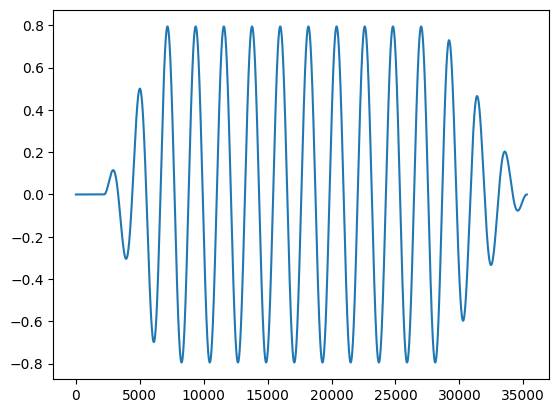

In [ ]:
plt.plot(list(tone(20, -2, 0.05, 0.1, 0.5, 0.15)))